In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_train = pd.read_csv("Files/train.csv", index_col="Id")
data_test = pd.read_csv("Files/test.csv", index_col="Id")

In [3]:
data_train["log_Sale_Price"] = np.log1p(data_train["SalePrice"])

In [4]:
data_train["SalePrice"]

Id
1       208500
2       181500
3       223500
4       140000
5       250000
         ...  
1456    175000
1457    210000
1458    266500
1459    142125
1460    147500
Name: SalePrice, Length: 1460, dtype: int64

In [5]:
#Null Werte raus

In [6]:
data_train.isnull().sum().sort_values(ascending=False)

PoolQC            1453
MiscFeature       1406
Alley             1369
Fence             1179
MasVnrType         872
                  ... 
ExterCond            0
ExterQual            0
Exterior2nd          0
Exterior1st          0
log_Sale_Price       0
Length: 81, dtype: int64

In [7]:
data_train["has_Pool"] = (data_train["PoolArea"] > 0).astype(int)
data_test["has_Pool"] = (data_test["PoolArea"] > 0).astype(int)

In [8]:
data_train["has_Misc"] = (data_train["MiscVal"] > 0).astype(int)
data_test["has_Misc"] = (data_test["MiscVal"] > 0).astype(int)

In [9]:
data_train = data_train.drop(columns=["PoolArea", "PoolQC"])
data_test = data_test.drop(columns=["PoolArea", "PoolQC"])

In [10]:
data_train = data_train.drop(columns=["MiscFeature", "MiscVal"])
data_test = data_test.drop(columns=["MiscFeature", "MiscVal"])

In [11]:
data_train["MasVnrType"].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [12]:
data_train[data_train['LotFrontage'].isna()]['BldgType'].value_counts()

BldgType
1Fam      226
TwnhsE     22
Duplex      5
Twnhs       3
2fmCon      3
Name: count, dtype: int64

In [13]:
data_train["BldgType"].value_counts()

BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64

In [14]:
data_train[data_train["BldgType"] == "1Fam"]["LotFrontage"].value_counts()

LotFrontage
60.0     122
80.0      67
70.0      64
50.0      50
75.0      48
        ... 
160.0      1
152.0      1
41.0       1
153.0      1
46.0       1
Name: count, Length: 104, dtype: int64

In [15]:
for df in [data_train, data_test]:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

In [17]:
na_meaning = {
    "Alley": "No Alley",
    "BsmtQual": "No Basement",
    "BsmtCond": "No Basement",
    "BsmtFinType1": "No Basement",
    "BsmtFinType2": "No Basement",
    "BsmtExposure": "No Basement",
    "FireplaceQu": "No Fireplace",
    "GarageType": "No Garage",
    "GarageFinish": "No Garage",
    "GarageQual": "No Garage",
    "GarageCond": "No Garage",
    "GarageYrBlt": "No Garage",
    "Fence": "No Fence",
    "MasVnrType": "None",
    "MasVnrArea": 0,
}
for col, fill_val in na_meaning.items():
    data_train[col] = data_train[col].fillna(fill_val)
    data_test[col] = data_test[col].fillna(fill_val)

In [18]:
data_train["Electrical"] = data_train["Electrical"].fillna(data_train["Electrical"].mode()[0])

In [19]:
#Outlier

In [20]:
numericalcols = data_train.select_dtypes(include="number").columns
categorical_cols = data_train.select_dtypes(include=["object", "category"]).columns
numericalcols

/var/folders/p3/cbztfpt14vz2k7ybs5qwp4040000gn/T/ipykernel_32701/3589242536.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data_train.select_dtypes(include=["object", "category"]).columns


Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'MoSold', 'YrSold',
       'SalePrice', 'log_Sale_Price', 'has_Pool', 'has_Misc'],
      dtype='str')

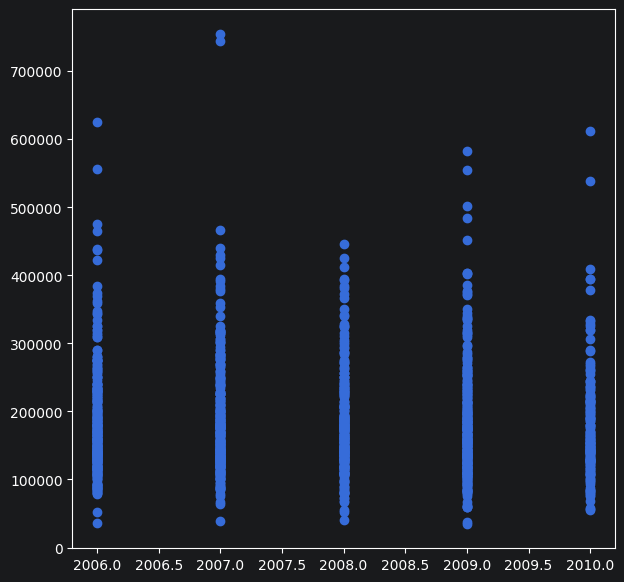

In [21]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x = data_train["YrSold"], y=data_train["SalePrice"]);
#ax.scatter(x = data_train["GarageArea"], y=data_train["log_Sale_Price"]);

In [22]:
data_train.LotArea.describe()

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
25%        7553.500000
50%        9478.500000
75%       11601.500000
max      215245.000000
Name: LotArea, dtype: float64

In [23]:
upper = data_train["EnclosedPorch"].quantile(0.999)
data_train['EnclosedPorch'] = data_train["EnclosedPorch"].clip(upper=upper)

In [24]:
upper_cl_porch = data_train["LotArea"].quantile(0.992)
data_train['LotArea'] = data_train["LotArea"].clip(upper=upper)

In [25]:
data_train.loc[data_train["BsmtFinSF2"] > 1400]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,Fence,MoSold,YrSold,SaleType,SaleCondition,SalePrice,log_Sale_Price,has_Pool,has_Misc
Id,,,,,,,,,,,,,,,,,,,,,
323,60,RL,86.0,360.296,Pave,No Alley,IR1,Lvl,AllPub,Inside,...,0,MnPrv,8,2007,WD,Normal,301000,12.614869,0,0


In [26]:
#Problematische Zeilen (hohe qualität und generell Werte, aber niedrige Qualität)
data_train = data_train.drop(index=1299)
data_train = data_train.drop(index=524)
#Mehr Gerage als Wohnfläche
data_train = data_train.drop(index=1062)

In [27]:
data_train[data_train["LowQualFinSF"] > 550]
#der eine Eintrag ist Qualität 10 und aus 1892 und einen realistischen Preis, also kein fragwürdiger Ausreißer

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,Fence,MoSold,YrSold,SaleType,SaleCondition,SalePrice,log_Sale_Price,has_Pool,has_Misc
Id,,,,,,,,,,,,,,,,,,,,,
186,75,RM,90.0,360.296,Pave,No Alley,IR2,Lvl,AllPub,Inside,...,410,GdPrv,6,2006,WD,Normal,475000,13.071072,0,0


In [28]:
data_train[data_train["BedroomAbvGr"] == 8]
#der Ausreißer hier hat mittlere Qualität und ist aus 1914, ist aber riesig. Sein Preis ist realistisch

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,Fence,MoSold,YrSold,SaleType,SaleCondition,SalePrice,log_Sale_Price,has_Pool,has_Misc
Id,,,,,,,,,,,,,,,,,,,,,
636,190,RH,60.0,360.296,Pave,Pave,Reg,Bnk,AllPub,Inside,...,0,No Fence,3,2007,WD,Abnorml,200000,12.206078,0,0


In [29]:
data_train[data_train["EnclosedPorch"] > 400][["OverallQual", "SalePrice", "GrLivArea", "Neighborhood", "EnclosedPorch"]]

,OverallQual,SalePrice,GrLivArea,Neighborhood,EnclosedPorch
Id,,,,,


In [30]:
data_train.loc[496, ['OpenPorchSF', 'GrLivArea', 'LotArea', 'YearBuilt', 'BldgType', 'SalePrice']]

OpenPorchSF        523
GrLivArea          720
LotArea        360.296
YearBuilt         1920
BldgType          1Fam
SalePrice        34900
Name: 496, dtype: object

In [31]:
#schiefe Variablen
skew_vals = data_train[numericalcols].skew().sort_values(ascending=False)

In [32]:
highly_skew_cols = skew_vals[(skew_vals >= 1) & (skew_vals.index != 'SalePrice')].index.tolist()
for col in highly_skew_cols:
    data_train[col] = np.log1p(data_train[col])
    data_test[col] = np.log1p(data_test[col])

In [ ]:
#Kateorische Spalten untersuchen

In [49]:
data_train["Exterior2nd"].value_counts()

Exterior2nd
VinylSd    504
MetalSd    213
HdBoard    207
Wd Sdng    197
Plywood    142
CmentBd     59
Wd Shng     38
BrkFace     25
Stucco      25
AsbShng     20
ImStucc     10
Brk Cmn      7
Stone        5
AsphShn      3
Other        1
CBlock       1
Name: count, dtype: int64

In [40]:
data_train.loc[data_train["Utilities"] != "AllPub"]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,Fence,MoSold,YrSold,SaleType,SaleCondition,SalePrice,log_Sale_Price,has_Pool,has_Misc
Id,,,,,,,,,,,,,,,,,,,,,
945,3.044522,RL,4.454347,360.296,Pave,No Alley,IR1,Lvl,NoSeWa,CulDSac,...,5.455321,No Fence,1,2009,COD,Abnorml,137500,11.831386,0.0,0.0


In [ ]:
#Street ist über 99% in einer Kategorie, binär und hat kaum eta squared
data_train = data_train.drop(columns="Street")
data_test = data_test.drop(columns="Street")
#Utilities hat alle bis auf eine Zeile in einer Kategorie
data_train = data_train.drop(columns="Utilities")
data_test = data_test.drop(columns="Utilities")

In [34]:
data_train.to_csv("train.csv")
data_test.to_csv("test.csv")